<a href="https://colab.research.google.com/github/jRicardo2003/JoseMiguel2507232022/blob/main/Notebooks/asociacionClaveB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CARGA DE DATOS**

En esta parte importe las librerias necesarias para la realizacion de este documento

*   Matplolib: para visualizar las graficas
*   apriori: para generacion de combinaciones frecuentes
*   para creacion de reglas de asociacion





In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
url ="https://raw.githubusercontent.com/jRicardo2003/JoseMiguel2507232022/refs/heads/main/data/clave_B_asociacion.csv"
df = pd.read_csv(url)
df.head()

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,B-T0001,B-C0076,2026-01-03,Salud,Alcohol,1,Tienda
1,B-T0001,B-C0076,2026-01-03,Medicamentos,Antigripal,1,Tienda
2,B-T0001,B-C0076,2026-01-03,Salud,Mascarilla,1,Tienda
3,B-T0001,B-C0076,2026-01-03,Bebes,Panal,1,Tienda
4,B-T0002,B-C0062,2026-03-26,Salud,Alcohol,1,App


**MOSTRAR PRIMERAS FILAS DEL DATASET**

In [22]:
df.head(10)

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,B-T0001,B-C0076,2026-01-03,Salud,Alcohol,1,Tienda
1,B-T0001,B-C0076,2026-01-03,Medicamentos,Antigripal,1,Tienda
2,B-T0001,B-C0076,2026-01-03,Salud,Mascarilla,1,Tienda
3,B-T0001,B-C0076,2026-01-03,Bebes,Panal,1,Tienda
4,B-T0002,B-C0062,2026-03-26,Salud,Alcohol,1,App
5,B-T0002,B-C0062,2026-03-26,Medicamentos,Antigripal,1,App
6,B-T0002,B-C0062,2026-03-26,Cuidado,Crema,2,App
7,B-T0003,B-C0067,2026-01-21,Medicamentos,Analgesico,2,Tienda
8,B-T0003,B-C0067,2026-01-21,Salud,Mascarilla,4,Tienda
9,B-T0003,B-C0067,2026-01-21,Bienestar,Proteina,2,Tienda


**ESTRUCTURA DEL DATASET**

El dataset esta compuesto por 7 columnas que presentan informacion relacionada con transacciones comerciales como: transaccion_id, cliente_id, fecha, item, cantidad, canal, cada fila representa un producto adquirido dentro de una transaccion especificac.

In [23]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(603, 7)


In [24]:
print("Nombres de columnas:")
print(df.columns)

Nombres de columnas:
Index(['transaccion_id', 'cliente_id', 'fecha', 'categoria', 'item',
       'cantidad', 'canal'],
      dtype='object')


VERIFICACION DE VALORES NULOS, DUPLICADOS Y TIPOS DE DATOS

In [25]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64


In [26]:
print("Cantidad de registros duplicados:")
print(df.duplicated().sum())

Cantidad de registros duplicados:
1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  603 non-null    object
 1   cliente_id      603 non-null    object
 2   fecha           603 non-null    object
 3   categoria       603 non-null    object
 4   item            603 non-null    object
 5   cantidad        603 non-null    int64 
 6   canal           602 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.1+ KB


**Preparar los datos en formato adecuado para aplicar reglas de asociación**



1.  Los datos fueron reorganizados agrupando los productos por transacción.
1.  Posteriormente se aplicó una conversión binaria para indicar únicamente si un producto fue comprado o no dentro de cada transacción.
2. Este formato es requerido para ejecutar correctamente el algoritmo Apriori.






In [28]:
basket = (df
          .groupby(['transaccion_id', 'item'])['cantidad']
          .sum()
          .unstack()
          .fillna(0))

In [29]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()
#codigo de conversion binaria


item,Alcohol,Analgesico,Antiacido,Antigripal,Biberon,Bloqueador,Crema,Curitas,Electrolitos,Formula,Gel,Jabon,Mascarilla,Panal,Proteina,Shampoo,Te_relajante,Termometro,Toallitas,Vitaminas
transaccion_id,,,,,,,,,,,,,,,,,,,,
B-T0001,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
B-T0002,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
B-T0003,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
B-T0004,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
B-T0005,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


**Aplicar el algoritmo Apriori o una técnica equivalente**

In [30]:
!pip install mlxtend

In [31]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [32]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items.head()

#Se aplicó el algoritmo Apriori utilizando un soporte mínimo de 0.02.
#El soporte representa la frecuencia con la que aparece una combinación de productos dentro del total de transacciones.


,support,itemsets
0,0.235294,(Alcohol)
1,0.070588,(Analgesico)
2,0.158824,(Antiacido)
3,0.270588,(Antigripal)
4,0.141176,(Biberon)


In [33]:
frequent_items.sort_values(by='support', ascending=False).head(10)
#Las combinaciones mostradas representan los productos o grupos de productos con mayor frecuencia de compra dentro del dataset.


,support,itemsets
19,0.294118,(Vitaminas)
12,0.282353,(Mascarilla)
3,0.270588,(Antigripal)
13,0.252941,(Panal)
14,0.247059,(Proteina)
0,0.235294,(Alcohol)
6,0.229412,(Crema)
18,0.223529,(Toallitas)
5,0.200000,(Bloqueador)
57,0.170588,"(Mascarilla, Antigripal)"


**Generar reglas de asociación usando soporte, confianza y lift**

In [34]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules.head()

#Se utilizaron las siguientes métricas:
# Soporte: frecuencia con la que aparece la combinación.
# Confianza: probabilidad de que un producto sea comprado junto con otro.
#Lift: mide la fuerza de la relación entre productos.
#Un lift mayor que 1 indica una relación positiva entre los artículos.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Antigripal),(Alcohol),0.270588,0.235294,0.152941,0.565217,2.402174,1.0,0.089273,1.758824,0.800248,0.433333,0.431438,0.607609
1,(Alcohol),(Antigripal),0.235294,0.270588,0.152941,0.650000,2.402174,1.0,0.089273,2.084034,0.763314,0.433333,0.520161,0.607609
2,(Alcohol),(Curitas),0.235294,0.123529,0.041176,0.175000,1.416667,1.0,0.012111,1.062389,0.384615,0.129630,0.058725,0.254167
3,(Curitas),(Alcohol),0.123529,0.235294,0.041176,0.333333,1.416667,1.0,0.012111,1.147059,0.335570,0.129630,0.128205,0.254167
4,(Electrolitos),(Alcohol),0.111765,0.235294,0.047059,0.421053,1.789474,1.0,0.020761,1.320856,0.496689,0.156863,0.242915,0.310526


**Mostrar las 10 reglas más relevantes**

In [35]:
top_rules = rules.sort_values(by='lift', ascending=False)

top_rules[['antecedents',
           'consequents',
           'support',
           'confidence',
           'lift']].head(10)
#Las reglas fueron ordenadas según el valor de lift para identificar las asociaciones más fuertes entre productos.


,antecedents,consequents,support,confidence,lift
544,"(Electrolitos, Alcohol)","(Te_relajante, Mascarilla, Antigripal)",0.023529,0.500000,17.000000
533,"(Te_relajante, Mascarilla, Antigripal)","(Electrolitos, Alcohol)",0.023529,0.800000,17.000000
529,"(Te_relajante, Mascarilla, Alcohol)","(Electrolitos, Antigripal)",0.023529,0.666667,16.190476
548,"(Electrolitos, Antigripal)","(Te_relajante, Mascarilla, Alcohol)",0.023529,0.571429,16.190476
546,"(Mascarilla, Electrolitos)","(Te_relajante, Antigripal, Alcohol)",0.023529,0.444444,12.592593
531,"(Te_relajante, Antigripal, Alcohol)","(Mascarilla, Electrolitos)",0.023529,0.666667,12.592593
538,"(Mascarilla, Electrolitos, Antigripal)","(Te_relajante, Alcohol)",0.023529,0.571429,12.142857
535,"(Mascarilla, Electrolitos, Alcohol)","(Te_relajante, Antigripal)",0.023529,0.571429,12.142857
423,"(Electrolitos, Antigripal)","(Te_relajante, Alcohol)",0.023529,0.571429,12.142857
422,"(Te_relajante, Alcohol)","(Electrolitos, Antigripal)",0.023529,0.500000,12.142857


**Interpretar al menos 5 reglas con lenguaje de negocio.**

In [ ]:
# Regla 1
#Los clientes que compran Electrolitos y Alcohol también suelen adquirir Té relajante, Mascarilla y Antigripal.
#Esta asociación presenta un lift de 17, lo que indica una relación muy fuerte entre estos productos. Esto puede representar patrones de compra relacionados con síntomas de enfermedad o cuidado de salud.

#Regla 2
#Cuando los clientes compran Té relajante, Mascarilla y Antigripal, existe una alta probabilidad de que también compren Electrolitos y Alcohol.
#La confianza de 0.80 indica que el 80% de las veces esta combinación ocurre dentro de las transacciones analizadas.

#Regla 3
#La relación entre Mascarilla, Electrolitos y Alcohol con Té relajante y Antigripal evidencia un comportamiento de compra asociado al cuidado personal y tratamiento de síntomas comunes.
#Esto representa oportunidades para promociones cruzadas en productos de salud.

#Regla 4
#Los productos Antigripal y Electrolitos muestran una fuerte asociación con Té relajante y Alcohol, indicando que muchos consumidores adquieren estos productos de forma complementaria.
#Esta información puede ser útil para recomendaciones automáticas de compra.

#Regla 5
#Las reglas con altos valores de lift muestran que los productos relacionados con salud, hidratación y cuidado preventivo suelen comprarse conjuntamente.
#La empresa podría utilizar estos patrones para diseñar combos comerciales y mejorar las estrategias de ventas.


**Proponer al menos 3 recomendaciones comerciales basadas en los resultados**

In [ ]:
#1. Crear promociones combinadas entre productos relacionados con salud y cuidado personal, como Antigripal, Mascarilla y Electrolitos.
#2. Implementar estrategias de venta cruzada recomendando automáticamente productos asociados durante el proceso de compra.
#3. Diseñar paquetes promocionales enfocados en temporadas de gripe o enfermedades respiratorias utilizando las combinaciones detectadas por el algoritmo.
#4. Colocar productos asociados en zonas cercanas dentro de la tienda física o plataformas digitales para aumentar las ventas complementarias.


**GRADICO DE REGLAS MAS FUERTES**

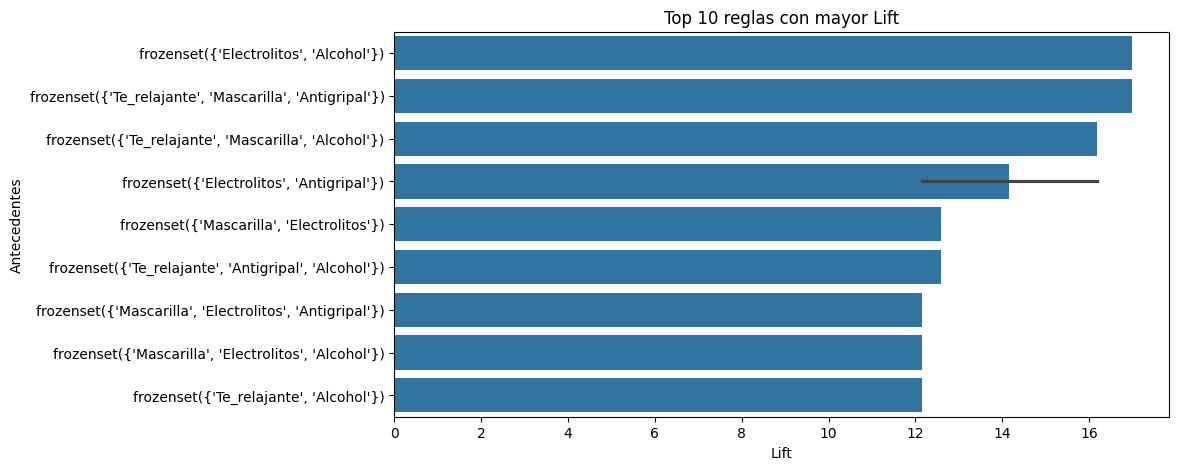

In [36]:
top10 = top_rules.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10['lift'],
    y=top10['antecedents'].astype(str)
)

plt.title("Top 10 reglas con mayor Lift")
plt.xlabel("Lift")
plt.ylabel("Antecedentes")

plt.show()